# Exact Ω Computation
**목적:** 각 레이어에 대해 `Δθ_i^T H_ii Δθ_i` (exact block-diagonal Hessian quadratic form)을 계산

현재 CSV에 있는 `Tr(H_ii) × ‖Δθ_i‖²` (trace approximation)와 비교하기 위함.

**방법:** Hessian-vector product (HVP) via double-backprop
```
g = ∂L/∂θ_i  (with create_graph=True)
Hv = ∂(g·v)/∂θ_i  where v = Δθ_i
exact_Ω_i = Δθ_i · Hv
```

**출력:** `results/csv/hawq_exact_omega.csv`

In [2]:
# ============================================================
# STEP 1  (처음 또는 새 런타임)
# 이 셀 실행 → 완료 후 Runtime > Restart runtime → STEP 2
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import sys, os
BASE = '/content/drive/MyDrive/MambaCompression/MambaIC'
sys.path.insert(0, BASE)
os.chdir(BASE)

exec(open('/content/drive/MyDrive/MambaCompression/setup_colab.py').read())

print()
print('=' * 60)
print('  완료.  Runtime > Restart runtime  후 STEP 2부터 실행')
print('=' * 60)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== 1. Core Dependencies ===
[  0.0s] pip install core deps...
[  5.2s] core deps done

=== 2. VMamba CUDA Kernel (ss2d) ===
Current GPU: NVIDIA A100-SXM4-40GB (sm_80)
Cache arch matches current GPU (sm_80) ✓
Cache found! Restoring 1 kernel files...
[  7.0s] copying .so from cache...
  Restored: selective_scan_cuda_oflex.cpython-312-x86_64-linux-gnu.so -> /usr/local/lib/python3.12/dist-packages/selective_scan_cuda_oflex.cpython-312-x86_64-linux-gnu.so
[  7.0s] .so copy done
[  7.0s] importing selective_scan_cuda_oflex...
[  7.0s] selective_scan_cuda_oflex imported OK (sm_80)
selective_scan_cuda_oflex imported OK (sm_80)
[  7.0s] setup_colab.py done

=== Setup Complete ===
Project: /content/drive/MyDrive/MambaCompression

  완료.  Runtime > Restart runtime  후 STEP 2부터 실행


In [3]:
# ============================================================
# STEP 2  (재시작 후 여기서부터 실행, 아래로 순서대로)
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import sys, os
BASE = '/content/drive/MyDrive/MambaCompression/MambaIC'
sys.path.insert(0, BASE)
os.chdir(BASE)

# 캐시에서 CUDA 커널 복원 (~5초)
exec(open('/content/drive/MyDrive/MambaCompression/setup_colab.py').read())

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from ModularModels import ModularAE
from train_ae import CsiDataset, NMSELoss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}  |  numpy {np.__version__}  |  torch {torch.__version__}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== 1. Core Dependencies ===
[  0.0s] pip install core deps...
[  5.2s] core deps done

=== 2. VMamba CUDA Kernel (ss2d) ===
Current GPU: NVIDIA A100-SXM4-40GB (sm_80)
Cache arch matches current GPU (sm_80) ✓
Cache found! Restoring 1 kernel files...
[  5.2s] copying .so from cache...
  Restored: selective_scan_cuda_oflex.cpython-312-x86_64-linux-gnu.so -> /usr/local/lib/python3.12/dist-packages/selective_scan_cuda_oflex.cpython-312-x86_64-linux-gnu.so
[  5.2s] .so copy done
[  5.2s] importing selective_scan_cuda_oflex...
[  5.2s] selective_scan_cuda_oflex imported OK (sm_80)
selective_scan_cuda_oflex imported OK (sm_80)
[  5.2s] setup_colab.py done

=== Setup Complete ===
Project: /content/drive/MyDrive/MambaCompression
Device: cuda  |  numpy 2.4.2  |  torch 2.10.0+cu128


In [ ]:
MODEL_PATH = 'saved_models/mamba_transnet_L2_dim512_baseline/best.pth'
DATA_PATH  = 'data/DATA_Htestout.mat'
BATCH_SIZE = 8
N_BATCHES  = 50

model = ModularAE(encoder_type='mamba', decoder_type='transnet',
                  encoded_dim=512, decoder_layers=2)
ck = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(ck['state_dict'], strict=False)
model = model.to(device).eval()
print(f'Model loaded (epoch={ck["epoch"]})')

dataset = CsiDataset(DATA_PATH)
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
print(f'Dataset: {len(dataset)} samples')

[INFO] Building: UE Encoder [mamba-L2] + BS Decoder [transnet-L2]


/content/drive/MyDrive/MambaCompression/MambaIC/models/VSS_module.py:56: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd
/content/drive/MyDrive/MambaCompression/MambaIC/models/VSS_module.py:64: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_bwd
/content/drive/MyDrive/MambaCompression/MambaIC/models/VSS_module.py:217: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd
/content/drive/MyDrive/MambaCompression/MambaIC/models/VSS_module.py:225: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_bwd
/content/drive/MyDrive/MambaCompre

Model loaded (epoch=354)
Dataset: 20000 samples


In [5]:
def quantize(w, bits):
    if bits >= 16:
        return w.clone()
    qmax  = 2 ** (bits - 1) - 1
    scale = w.abs().max().clamp(min=1e-8) / qmax
    return (w / scale).round().clamp(-qmax, qmax) * scale

def delta(w, bits):
    return (quantize(w, bits) - w).detach()

print('Quantize functions defined')

Quantize functions defined


In [6]:
FC_CHUNK = 16

LAYER_MAP = {
    'stem.0':                  ('encoder.stem.0.weight',              None),
    'layers.0.vss.1.in_proj':  ('encoder.layers.0.vss.1.in_proj.weight',  None),
    'layers.0.vss.1.out_proj': ('encoder.layers.0.vss.1.out_proj.weight', None),
    'layers.0.vss.1.conv2d':   ('encoder.layers.0.vss.1.conv2d.weight',   None),
    'layers.1.vss.1.in_proj':  ('encoder.layers.1.vss.1.in_proj.weight',  None),
    'layers.1.vss.1.out_proj': ('encoder.layers.1.vss.1.out_proj.weight', None),
    'layers.1.vss.1.conv2d':   ('encoder.layers.1.vss.1.conv2d.weight',   None),
    'proj_conv':               ('encoder.proj_conv.weight',               None),
}
for k in range(32):
    LAYER_MAP[f'fc_part{k}'] = ('encoder.fc.weight', (k * FC_CHUNK, (k + 1) * FC_CHUNK))

param_dict = dict(model.named_parameters())
BITS = [16, 8, 4, 2]
print(f'{len(LAYER_MAP)} layers to process')

40 layers to process


In [7]:
from train_ae import NMSELoss

criterion = NMSELoss()
omega_acc = {ln: {b: 0.0 for b in BITS} for ln in LAYER_MAP}
n_done = 0

for ln, (pname, chunk) in LAYER_MAP.items():
    param = param_dict[pname]

    for bits in BITS:
        if chunk is None:
            dtheta = delta(param, bits).to(device)
            v = dtheta
        else:
            r0, r1 = chunk
            dtheta = delta(param[r0:r1, :], bits).to(device)
            v = torch.zeros_like(param)
            v[r0:r1, :] = dtheta

        if dtheta.abs().max() < 1e-10:
            omega_acc[ln][bits] = 0.0
            continue

        batch_sum, batch_cnt = 0.0, 0
        for b_idx, x in enumerate(loader):
            if b_idx >= N_BATCHES:
                break
            x = x.to(device)
            with torch.enable_grad():
                recon = model(x)
                loss  = criterion(recon, x)
            g  = torch.autograd.grad(loss, param, create_graph=True)[0]
            Hv = torch.autograd.grad((g * v).sum(), param, retain_graph=False)[0]
            if chunk is None:
                batch_sum += (v * Hv).sum().item()
            else:
                batch_sum += (dtheta * Hv[r0:r1, :]).sum().item()
            batch_cnt += 1
            del loss, recon, g, Hv
            torch.cuda.empty_cache()

        omega_acc[ln][bits] = batch_sum / max(batch_cnt, 1)

    n_done += 1
    vals = [f'W{b}={omega_acc[ln][b]:.3e}' for b in BITS]
    print(f'[{n_done:3d}/{len(LAYER_MAP)}] {ln:35s}  ' + '  '.join(vals))

print('Done')

: 

: 

: 

In [ ]:
rows = []
for ln, (pname, chunk) in LAYER_MAP.items():
    param = param_dict[pname]
    n_p   = param[chunk[0]:chunk[1], :].numel() if chunk else param.numel()
    rows.append({
        'Layer':          ln,
        'Params':         n_p,
        'ExactOmg_INT16': omega_acc[ln][16],
        'ExactOmg_INT8':  omega_acc[ln][8],
        'ExactOmg_INT4':  omega_acc[ln][4],
        'ExactOmg_INT2':  omega_acc[ln][2],
    })

df_exact = pd.DataFrame(rows)
df_trace = pd.read_csv('results/csv/hawq_importance_split.csv')
df_cmp   = df_exact.merge(
    df_trace[['Layer', 'Omg_INT8', 'Omg_INT4', 'Omg_INT2']], on='Layer', how='left')
df_cmp['Ratio_INT8'] = df_cmp['ExactOmg_INT8'] / df_cmp['Omg_INT8'].clip(lower=1e-15)
df_cmp['Ratio_INT4'] = df_cmp['ExactOmg_INT4'] / df_cmp['Omg_INT4'].clip(lower=1e-15)

out_path = 'results/csv/hawq_exact_omega.csv'
df_cmp.to_csv(out_path, index=False)
print(f'Saved: {out_path}')
print(df_cmp[['Layer','ExactOmg_INT8','Omg_INT8','Ratio_INT8']].head(15).to_string())

Saved: results/csv/hawq_exact_omega.csv
                      Layer  ExactOmg_INT8  Omg_INT8  Ratio_INT8
0                    stem.0   7.543770e-04  0.912818    0.000826
1    layers.0.vss.1.in_proj  -1.754909e-06  0.010172   -0.000173
2   layers.0.vss.1.out_proj   1.343146e-05  0.014757    0.000910
3     layers.0.vss.1.conv2d  -1.781542e-06  0.000136   -0.013057
4    layers.1.vss.1.in_proj   5.046681e-05  0.149631    0.000337
5   layers.1.vss.1.out_proj   7.331887e-05  0.070973    0.001033
6     layers.1.vss.1.conv2d  -4.589346e-07  0.000805   -0.000570
7                 proj_conv   3.713600e-05  0.007328    0.005067
8                  fc_part0   6.351550e-06  0.187450    0.000034
9                  fc_part1   6.377159e-06  0.204750    0.000031
10                 fc_part2   8.409375e-06  0.226636    0.000037
11                 fc_part3   6.648768e-06  0.217078    0.000031
12                 fc_part4   6.594702e-06  0.179814    0.000037
13                 fc_part5   6.336006e-06  0.1826

Saved: results/plots/lemma1_exact_vs_approx.png
Saved: ../figures/lemma1_exact_vs_approx.pdf


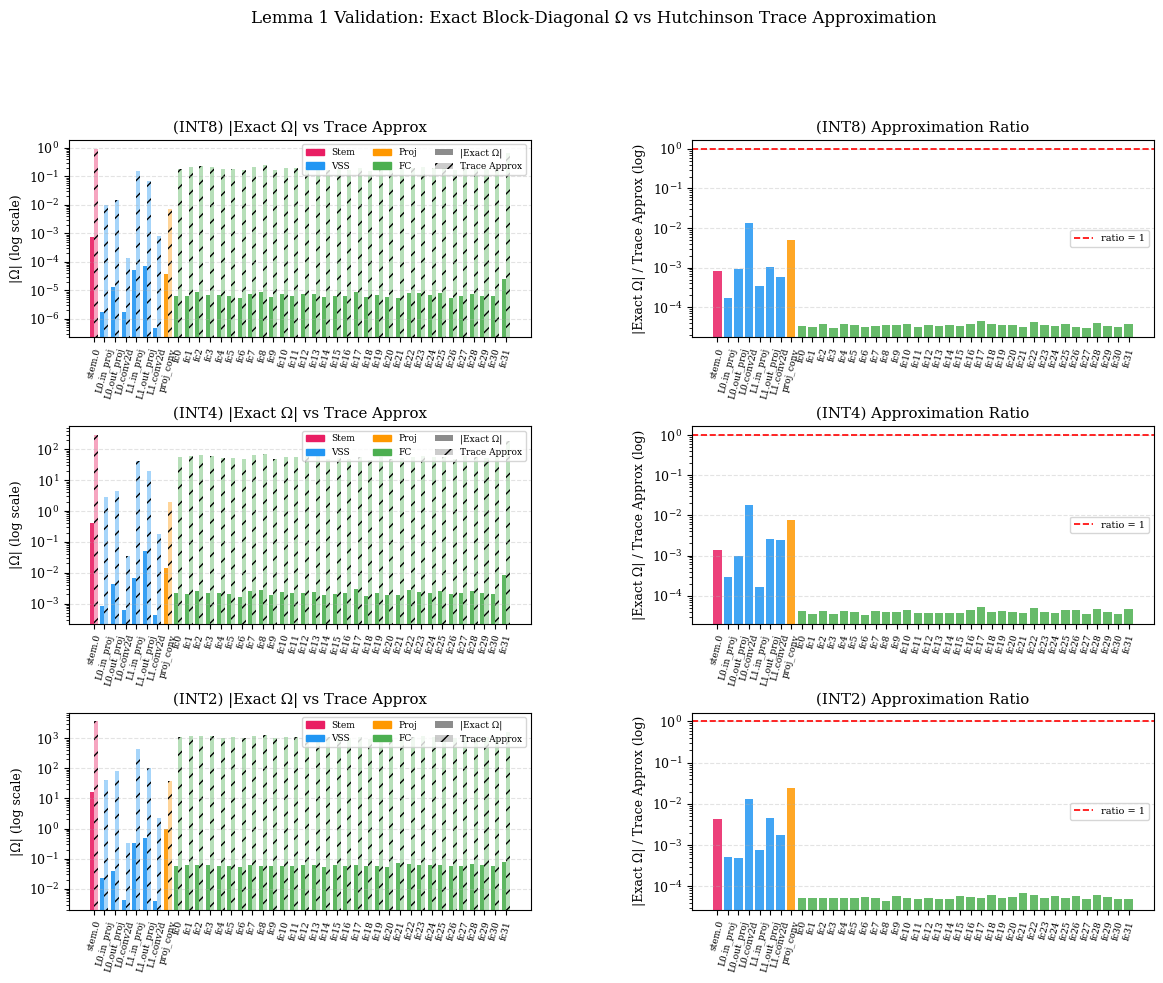


─── Ratio Summary (|Exact Ω| / Trace Approx) ───
  INT8: mean=5.77e-04  median=3.61e-05  max=1.31e-02
  INT4: mean=8.62e-04  median=4.08e-05  max=1.78e-02
  INT2: mean=1.29e-03  median=5.42e-05  max=2.44e-02


In [ ]:
# ============================================================
# Figure: Lemma 1 Validation — Exact Ω vs Trace Approximation
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

df = pd.read_csv('results/csv/hawq_exact_omega.csv')

# ── Layer grouping ──────────────────────────────────────────
def layer_group(name):
    if name.startswith('stem'):    return 'Stem'
    if 'vss' in name:              return 'VSS'
    if name.startswith('proj'):    return 'Proj'
    if name.startswith('fc'):      return 'FC'
    return 'Other'

df['Group'] = df['Layer'].apply(layer_group)

# ── Layer short labels ──────────────────────────────────────
def short_label(name):
    if name.startswith('fc_part'):
        return f"fc{name.split('fc_part')[1]}"
    return name.replace('layers.','L').replace('.vss.1.','.')

df['Label'] = df['Layer'].apply(short_label)

# ── Group colors ────────────────────────────────────────────
color_map = {'Stem':'#E91E63','VSS':'#2196F3','Proj':'#FF9800','FC':'#4CAF50'}
colors = df['Group'].map(color_map)

# ── Figure layout: 3 rows ───────────────────────────────────
plt.rcParams.update({'font.size':9,'font.family':'serif','mathtext.fontset':'stix'})
fig = plt.figure(figsize=(14, 10))
gs  = fig.add_gridspec(3, 2, hspace=0.45, wspace=0.35)

bits_list = [('INT8','ExactOmg_INT8','Omg_INT8'),
             ('INT4','ExactOmg_INT4','Omg_INT4'),
             ('INT2','ExactOmg_INT2','Omg_INT2')]

x = np.arange(len(df))
w = 0.38

for row, (bit_label, exact_col, approx_col) in enumerate(bits_list):
    if exact_col not in df.columns:
        continue

    exact  = df[exact_col].values
    approx = df[approx_col].values

    # ── (left) magnitude comparison (log scale) ─────────────
    ax1 = fig.add_subplot(gs[row, 0])
    ax1.bar(x - w/2, np.abs(exact),  w, color=colors, alpha=0.9, label='|Exact Ω|')
    ax1.bar(x + w/2, np.abs(approx), w, color=colors, alpha=0.4, label='Trace Approx Ω̄', hatch='//')
    ax1.set_yscale('log')
    ax1.set_xticks(x)
    ax1.set_xticklabels(df['Label'], rotation=75, fontsize=6.5)
    ax1.set_ylabel('|Ω| (log scale)')
    ax1.set_title(f'({bit_label}) |Exact Ω| vs Trace Approx')
    ax1.grid(axis='y', linestyle='--', alpha=0.35)

    # legend patches
    patches = [mpatches.Patch(color=c, label=g) for g, c in color_map.items() if g in df['Group'].values]
    patches += [mpatches.Patch(facecolor='gray', alpha=0.9, label='|Exact Ω|'),
                mpatches.Patch(facecolor='gray', alpha=0.4, hatch='//', label='Trace Approx')]
    ax1.legend(handles=patches, fontsize=6.5, ncol=3, loc='upper right')

    # ── (right) ratio |ExactΩ / TraceApprox| ────────────────
    ax2 = fig.add_subplot(gs[row, 1])
    ratio = np.abs(exact) / (np.abs(approx) + 1e-30)
    ax2.bar(x, ratio, color=colors, alpha=0.85)
    ax2.axhline(1.0, color='red', linestyle='--', linewidth=1.2, label='ratio = 1')
    ax2.set_yscale('log')
    ax2.set_xticks(x)
    ax2.set_xticklabels(df['Label'], rotation=75, fontsize=6.5)
    ax2.set_ylabel('|Exact Ω| / Trace Approx (log)')
    ax2.set_title(f'({bit_label}) Approximation Ratio')
    ax2.legend(fontsize=7)
    ax2.grid(axis='y', linestyle='--', alpha=0.35)

fig.suptitle('Lemma 1 Validation: Exact Block-Diagonal Ω vs Hutchinson Trace Approximation',
             fontsize=12, y=1.01)

out_png = 'results/plots/lemma1_exact_vs_approx.png'
out_pdf = '../figures/lemma1_exact_vs_approx.pdf'
os.makedirs(os.path.dirname(out_png), exist_ok=True)
os.makedirs(os.path.dirname(out_pdf), exist_ok=True)
fig.savefig(out_png, dpi=200, bbox_inches='tight')
fig.savefig(out_pdf, bbox_inches='tight')
print(f'Saved: {out_png}')
print(f'Saved: {out_pdf}')
plt.show()

# ── Summary stats ────────────────────────────────────────────
print('\n─── Ratio Summary (|Exact Ω| / Trace Approx) ───')
for _, (bit_label, exact_col, approx_col) in enumerate(bits_list):
    if exact_col not in df.columns: continue
    ratio = np.abs(df[exact_col].values) / (np.abs(df[approx_col].values) + 1e-30)
    print(f'  {bit_label}: mean={ratio.mean():.2e}  median={np.median(ratio):.2e}  max={ratio.max():.2e}')

In [ ]:
exec(open('measure_delta_L.py').read())

In [ ]:
import os, sys
BASE = '/content/drive/MyDrive/MambaCompression/MambaIC'
os.chdir(BASE)
if BASE not in sys.path:
    sys.path.insert(0, BASE)

__file__ = os.path.join(BASE, 'analysis', 'measure_per_layer_dL.py')
exec(open(__file__).read())

__file__ = os.path.join(BASE, 'analysis', 'plot_delta_L_decomposition.py')
exec(open(__file__).read())

__file__ = os.path.join(BASE, 'analysis', 'plot_per_layer_validation.py')
exec(open(__file__).read())